# Installing the package

Uncomment this line to download the package. For best results, install PyVaR in a fresh Python environment to avoid conflicts with existing packages.

In [1]:
#pip install git+https://github.com/Alessandro-Dodon/pyvar.git#subdirectory=package

---

## Notebook Overview

This notebook is entirely dedicated to basic **Value at Risk (VaR)** methods. We will cover four fundamental approaches: **Parametric VaR**, **Historical (Non-Parametric) VaR**, **Hybrid VaR**, and the **Cornish-Fisher Expansion**. For each method, we briefly explain the key concepts and formulas, followed by practical implementation using our Python package and sample data.


### Packages

We begin by importing the `pyvar` package along with other necessary libraries for data handling, analysis, and visualization. Ensure all required packages are installed in your environment before proceeding.

In [2]:
import pyvar as pv

In [3]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, skew, kurtosis
from scipy.stats import t

---

### Choosing a Single Asset Portfolio

We begin with basic VaR models using a single asset: the Vanguard Total World Stock ETF (VT). This ETF is widely used by both retail and institutional investors as a low-cost, diversified proxy for global equity markets.

While these models are univariate—meaning they analyze one asset at a time—you can apply them to your own portfolio by first computing daily portfolio returns. This is done by summing the monetary positions across assets for each day, then calculating the daily return series.

Note: All our models here use **daily data**.

Feel free to replace the ticker with another asset of interest. Popular choices include:
- S&P 500 Index (`SPY`)
- Apple (`AAPL`)
- Nvidia (`NVDA`)
- Microsoft (`MSFT`)
- Tesla (`TSLA`)

In [4]:
# Download the VT data from YF
vt_data = yf.download("VT", start="2000-01-01", end="2025-01-01")

# Check for missing values in the entire DataFrame (including the new column)
print(vt_data.isnull().sum())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price   Ticker
Close   VT        0
High    VT        0
Low     VT        0
Open    VT        0
Volume  VT        0
dtype: int64


In [5]:
# Compute log returns and remove the first NaN
vt_data["Log Returns"] = np.log(vt_data["Close"] / vt_data["Close"].shift(1))
vt_returns = vt_data["Log Returns"].dropna()

In [6]:
vt_returns.head()

Date
2008-06-27   -0.001615
2008-06-30    0.000807
2008-07-01   -0.008921
2008-07-02   -0.014773
2008-07-03    0.002684
Name: Log Returns, dtype: float64

If you want to **download and save the return series as a CSV**, you can do:

```python
vt_returns.to_csv("vt_returns.csv")
```

If you want to **load your own return series from a CSV**, use:

```python
vt_returns = pd.read_csv("your_file.csv", index_col=0, parse_dates=True).squeeze()
```

Make sure:
- The CSV contains one column of daily return values
- The first column becomes the date index
- Dates are properly parsed for the analysis
- Returns are already computed (not prices)

Note: You are responsible for return calculation and data cleaning.  

#### General Setup

We will always use a 99% confidence level, but feel free to experiment with 95% or 97.5%. We will start with investing $100K.

In [7]:
# Set parameters
confidence_level = 0.99 # <----- Can choose 0.95 etc
wealth = 100_000 # <----- Wealth invested in our ETF

---

### Parametric Normal Model

This is the simplest approach to estimate **Value-at-Risk (VaR)** and **Expected Shortfall (ES)**, assuming returns are Normally distributed.

VaR at confidence level $c$ is given by:

$$
\text{VaR}_\alpha = \sigma \cdot z_\alpha
$$

Where:
- $\sigma$ is the standard deviation of returns  
- $z_\alpha$ is the Normal quantile for $\alpha = 1 - c$

The **Expected Shortfall (ES)** has a closed-form under Normality:

$$
\text{ES}_\alpha = \sigma \cdot \frac{\phi(z_\alpha)}{\alpha}
$$

VaR and ES can be reported as **percentages** or **monetary values** if `wealth` is provided.

Since returns are assumed **i.i.d.**, multiday risk can be scaled by $\sqrt{h}$. However, the Normal model often **understates tail risk**, as financial returns typically show


In [8]:
# Apply Parametric VaR model 
parametric_normal_results = pv.parametric_var(vt_returns, confidence_level, distribution="normal", wealth=wealth) 

# Compute ES for the whole period
parametric_normal_results = pv.parametric_es(parametric_normal_results, confidence_level, distribution="normal", wealth=wealth) 


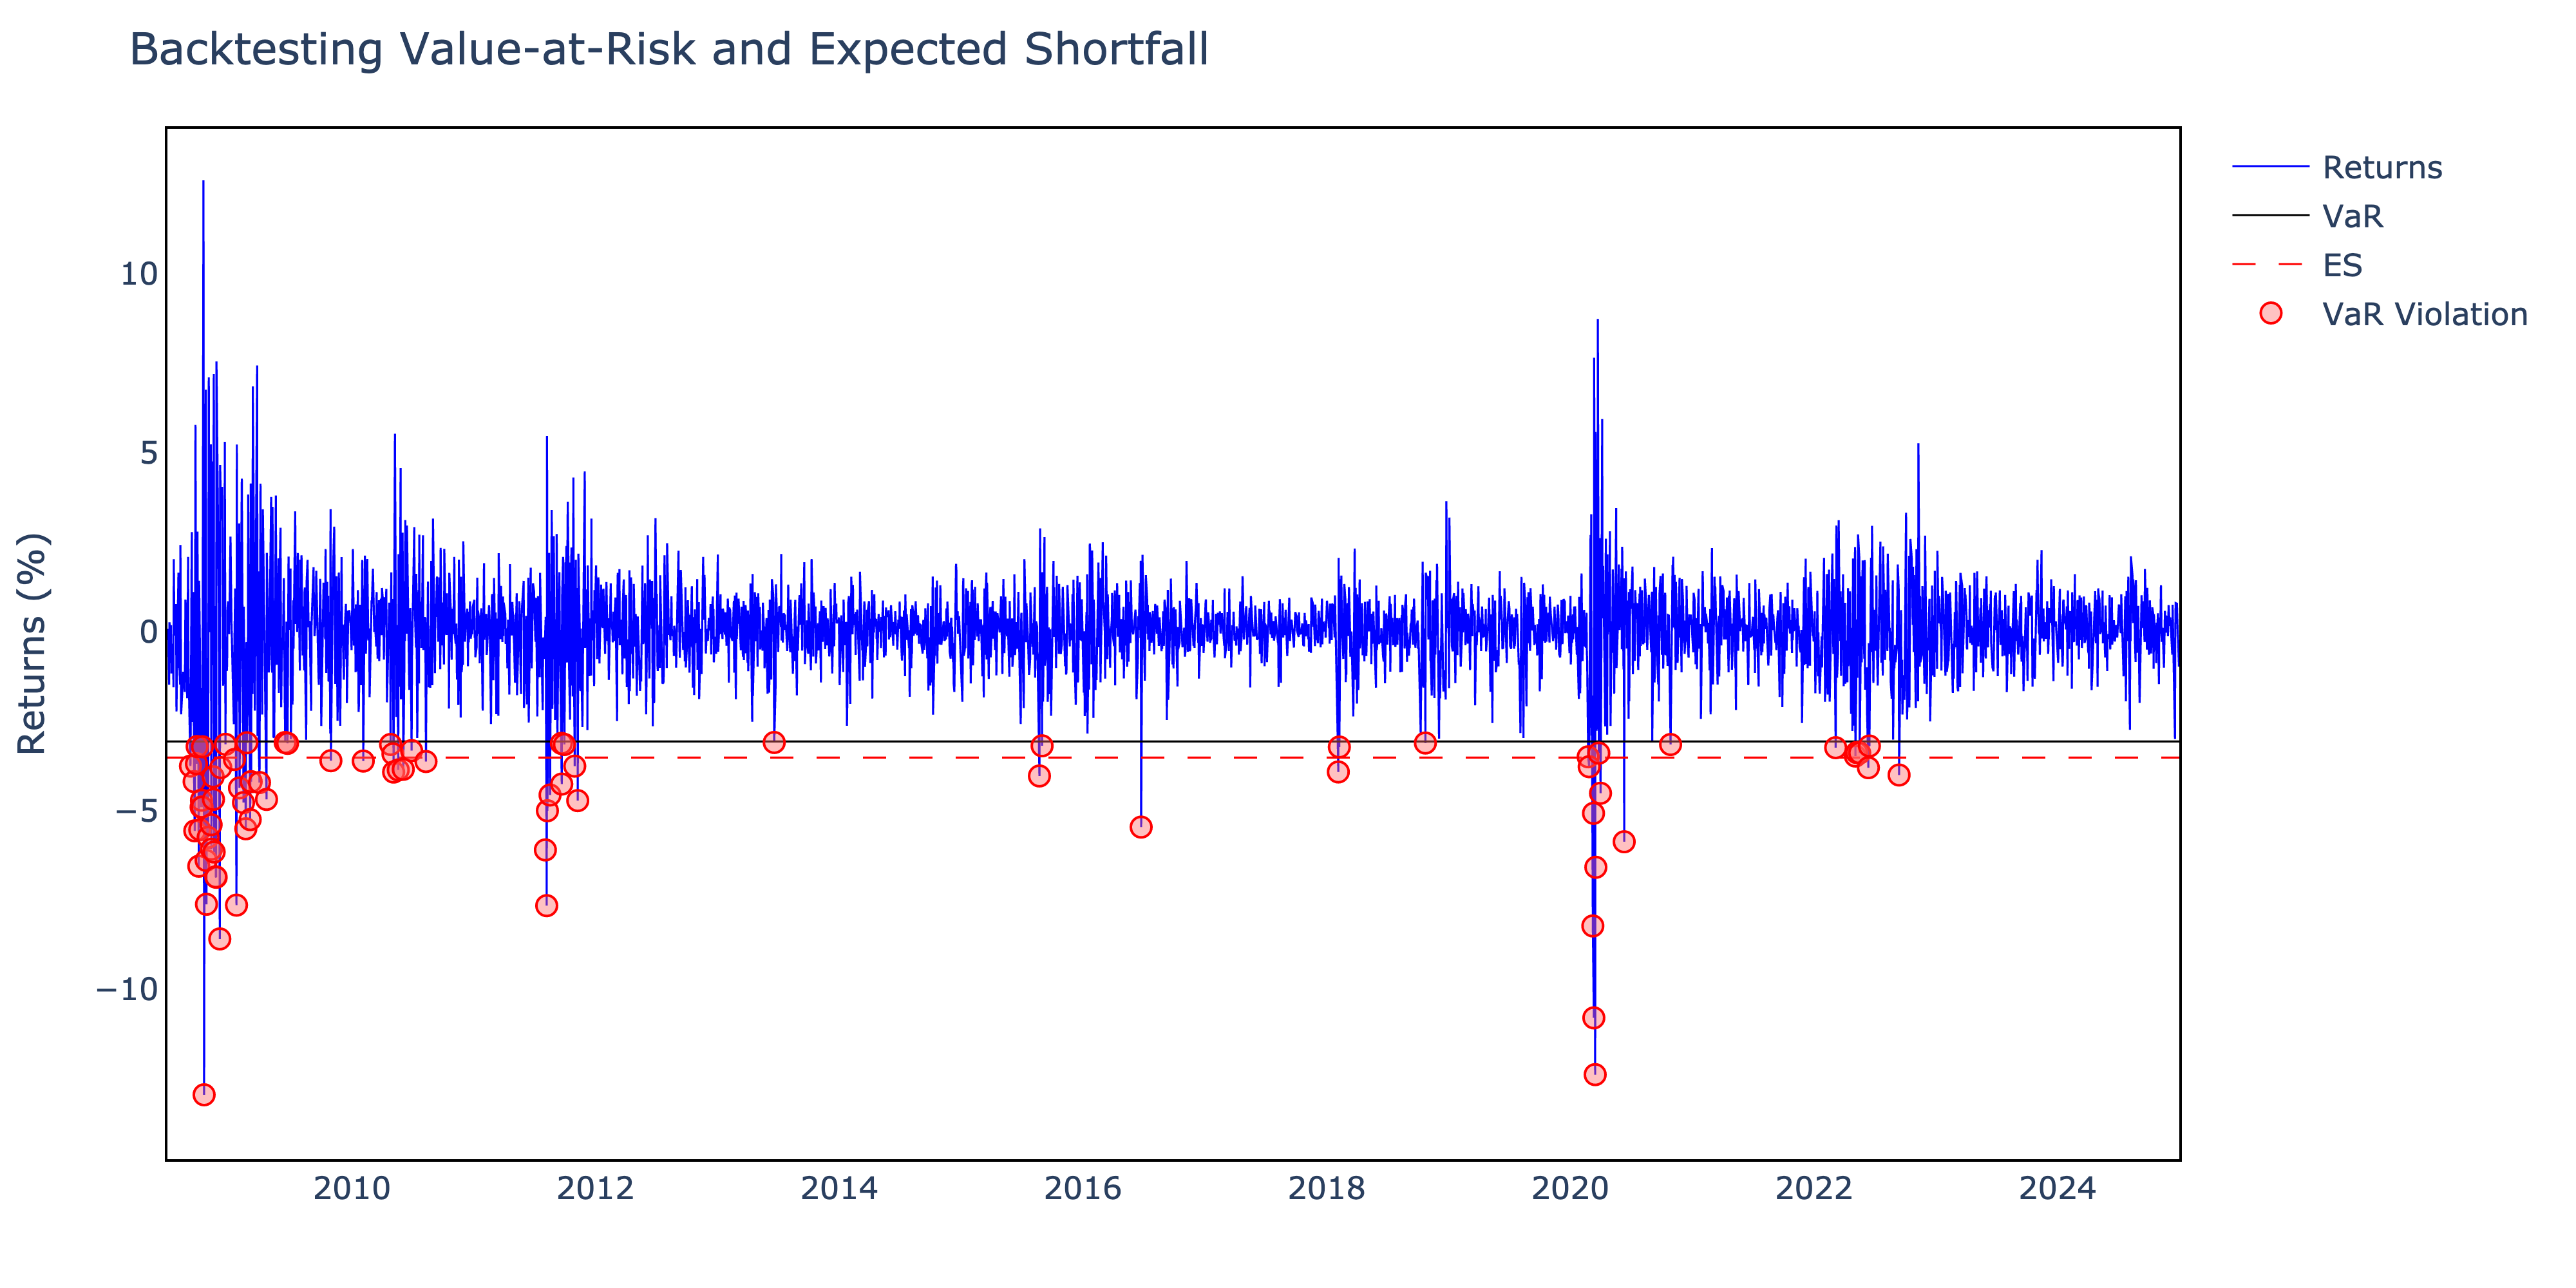

In [9]:
# Plot backtest
pv.plot_backtest(parametric_normal_results, interactive=False) 

In [10]:
parametric_normal_results.head()

,Returns,VaR,VaR Violation,VaR_monetary,ES,ES_monetary
Date,,,,,,
2008-06-27,-0.001615,0.030655,False,3065.525625,0.035121,3512.063943
2008-06-30,0.000807,0.030655,False,3065.525625,0.035121,3512.063943
2008-07-01,-0.008921,0.030655,False,3065.525625,0.035121,3512.063943
2008-07-02,-0.014773,0.030655,False,3065.525625,0.035121,3512.063943
2008-07-03,0.002684,0.030655,False,3065.525625,0.035121,3512.063943


#### Backtesting the Parametric Normal Model

The results below confirm the earlier warning about the Normal model underestimating tail risk: we observe **too many violations** for a 99% confidence level.

Also, the independence test fails, showing that violations are **clustered**. This reflects another limitation of the model — it assumes constant volatility over time (i.i.d. returns), which is clearly unrealistic for financial data.

_This highlights the need for models with time-varying volatility._



In [11]:
# Count violations
parametric_normal_violations, parametric_normal_violation_rate = pv.count_violations(parametric_normal_results)

# Kupiec Test (Unconditional Coverage)
parametric_normal_kupiec = pv.kupiec_test(
    total_violations=parametric_normal_violations,
    total_days=len(parametric_normal_results),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
parametric_normal_christoffersen = pv.christoffersen_test(parametric_normal_results)

# Joint Test (Conditional Coverage)
parametric_normal_joint = pv.joint_lr_test(
    LR_uc=parametric_normal_kupiec["LR_uc"],
    LR_c=parametric_normal_christoffersen["LR_c"]
)

In [12]:
# Summary output
print(f"\n--- Parametric Normal VaR Backtesting Summary ---")
print(f"Total Violations     : {parametric_normal_violations}")
print(f"Violation Rate       : {parametric_normal_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {parametric_normal_kupiec['LR_uc']:.4f}")
print(f"p-value             : {parametric_normal_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {parametric_normal_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {parametric_normal_christoffersen['LR_c']:.4f}")
print(f"p-value             : {parametric_normal_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {parametric_normal_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {parametric_normal_joint['LR_total']:.4f}")
print(f"p-value             : {parametric_normal_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {parametric_normal_joint['reject_null']}")


--- Parametric Normal VaR Backtesting Summary ---
Total Violations     : 80
Violation Rate       : 1.92%

Kupiec Test (UC):
LR_uc               : 28.2624
p-value             : 0.0000
Reject Null (5%)    : True

Christoffersen Test (Independence):
LR_c                : 14.5445
p-value             : 0.0001
Reject Null (5%)    : True

Joint Test (Conditional Coverage):
LR_total            : 42.8069
p-value             : 0.0000
Reject Null (5%)    : True


#### Normality Assumption and Financial Returns

The plot below illustrates the **fat tails of financial returns**, highlighting the significant deviation from the normal distribution. This clearly shows that relying on **the normality assumption underestimates the likelihood of extreme events**, making it a risky and misleading simplification in financial modeling.

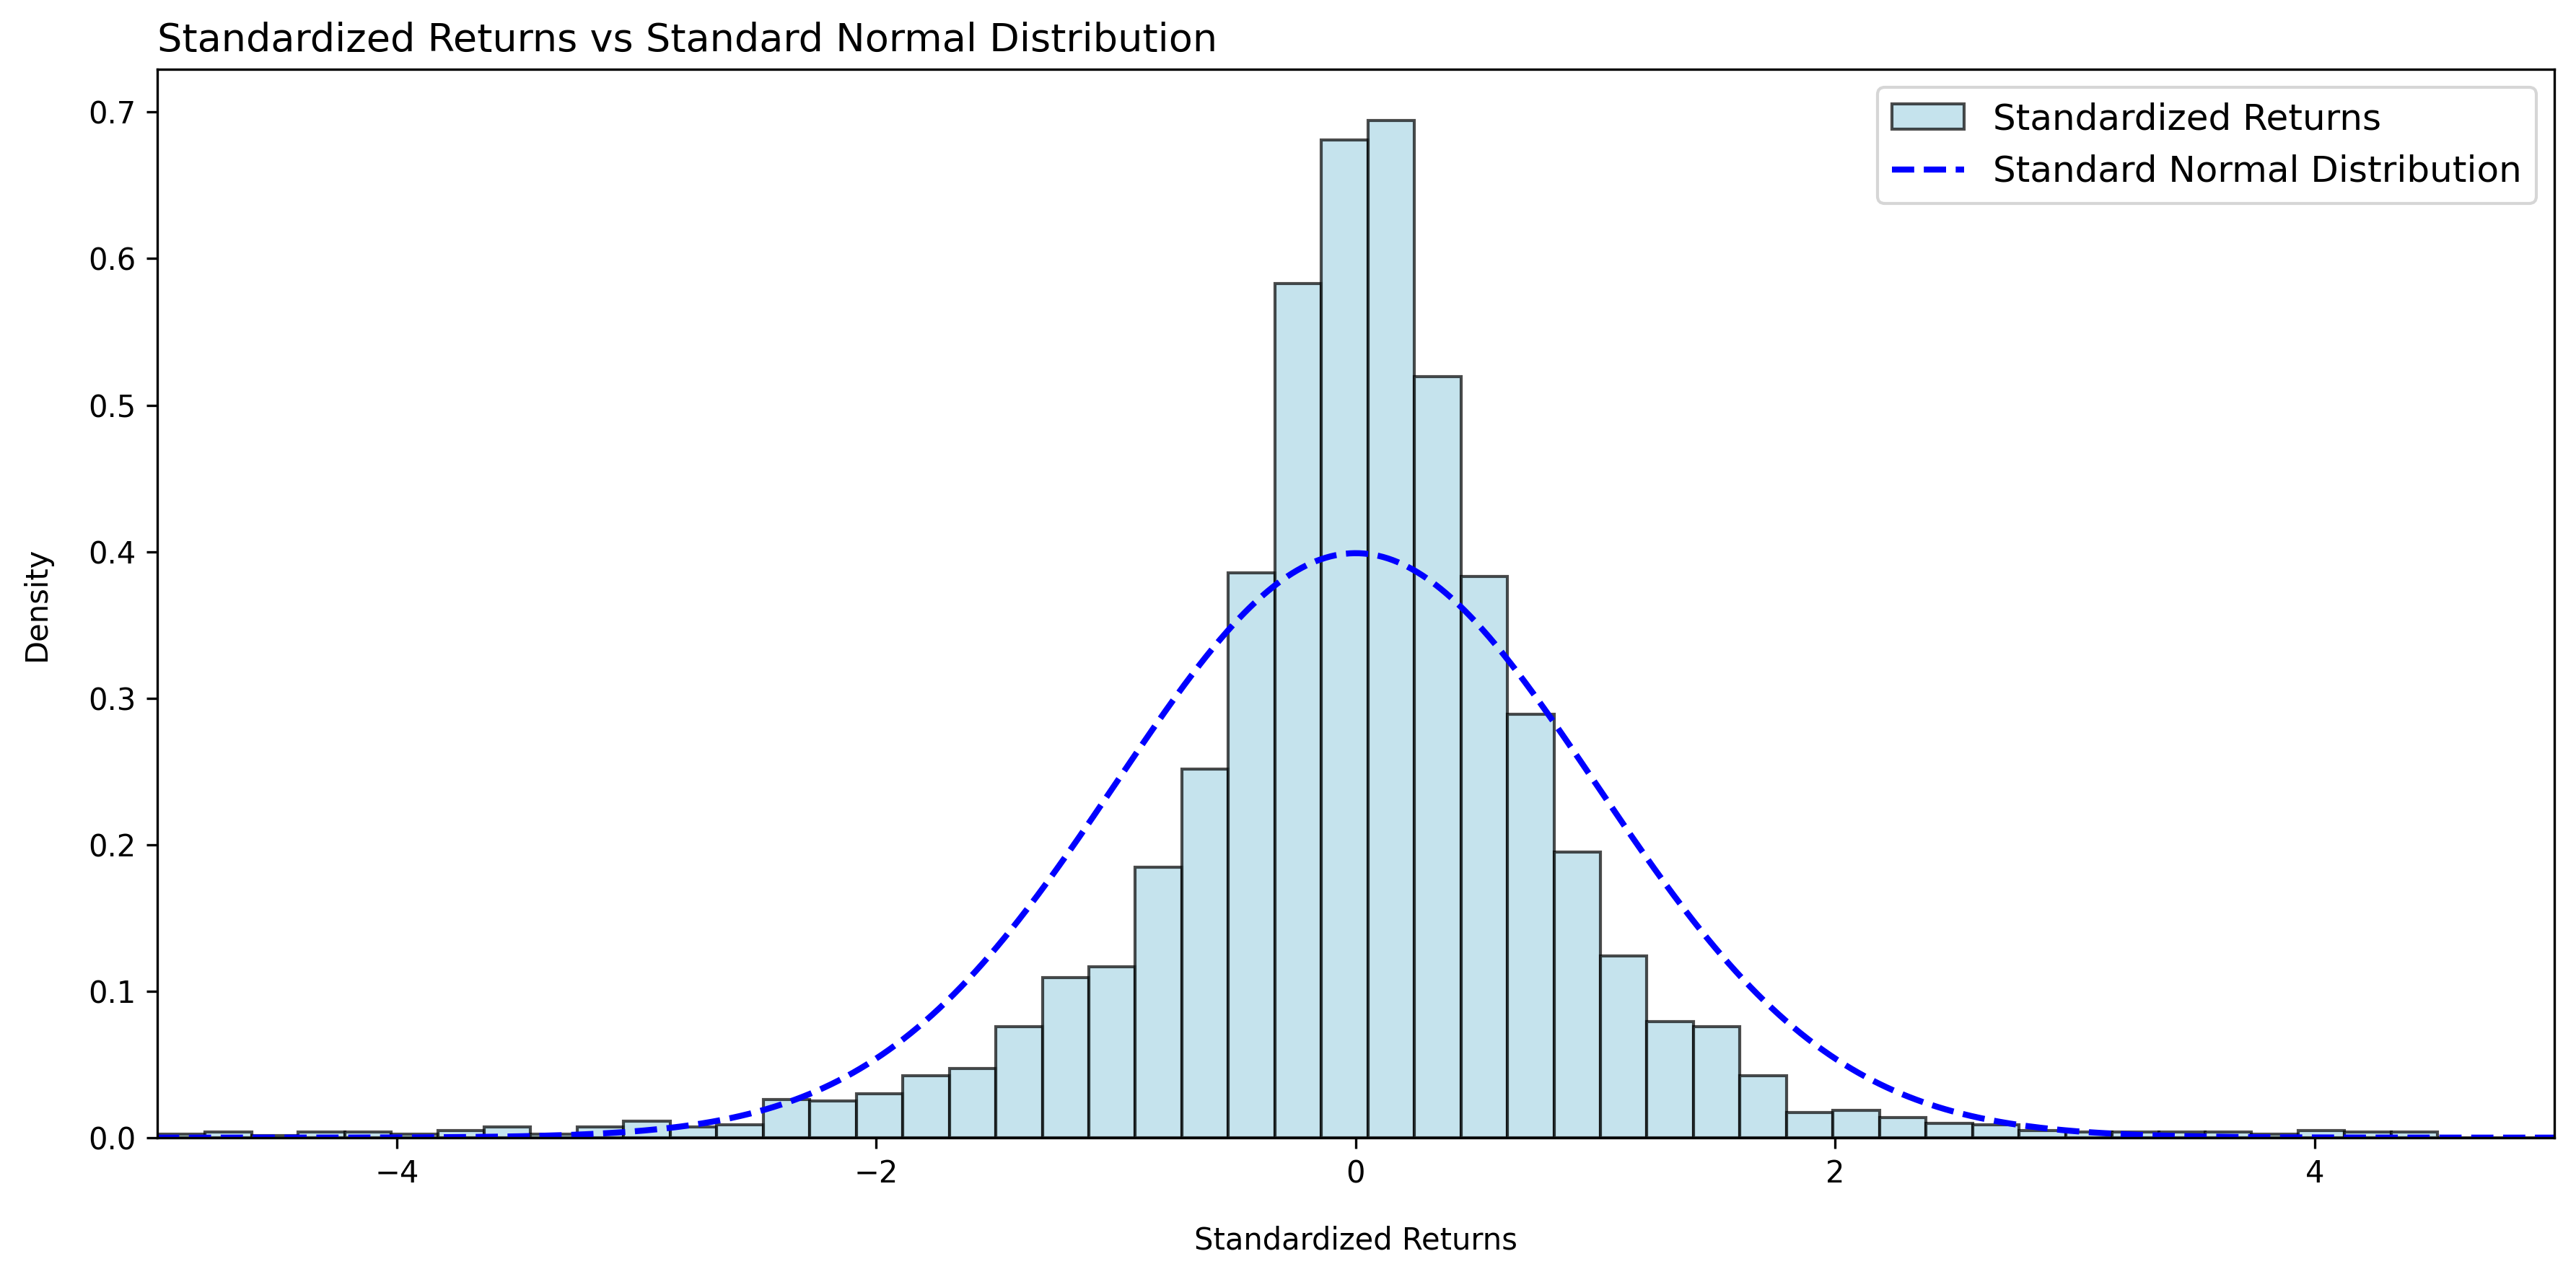

In [13]:
# Standardize the returns
mean_returns = np.mean(vt_returns)
std_returns = np.std(vt_returns)
standardized_returns = (vt_returns - mean_returns) / std_returns

# Standard normal PDF
x_grid = np.linspace(-5, 5, 1000)
normal_pdf = norm.pdf(x_grid)

# Plot
plt.figure(figsize=(12, 6), dpi=300)

# Histogram of standardized returns
plt.hist(
    standardized_returns,
    bins=100,
    density=True,
    color='lightblue',
    alpha=0.7,
    edgecolor='black',
    label='Standardized Returns'
)

# Standard normal curve
plt.plot(x_grid, normal_pdf, 'b--', linewidth=2, label='Standard Normal Distribution')

# X-axis limits
plt.xlim(-5, 5)

# Labels and styling
plt.title("Standardized Returns vs Standard Normal Distribution", loc="left", fontsize=13, fontweight="medium")
plt.xlabel("Standardized Returns", labelpad=12)
plt.ylabel("Density", labelpad=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

---

### Parametric Student-t Model

This model extends the Normal VaR by assuming returns follow a **Student-t distribution**, which captures **fat tails** often observed in financial data.

The t-distribution has an additional parameter: the **degrees of freedom (ν)**, which controls the heaviness of the tails. Lower ν means fatter tails, resulting in higher VaR and ES estimates compared to the Normal model.

While this approach improves tail risk estimation, it is still **symmetric**, so it does not account for **skewness** in the return distribution.


In [14]:
# Apply Parametric VaR model 
parametric_t_results = pv.parametric_var(vt_returns, confidence_level, distribution="t", wealth=wealth) 

# Compute ES for the whole period
parametric_t_results = pv.parametric_es(parametric_t_results, confidence_level, distribution="t", wealth=wealth) 


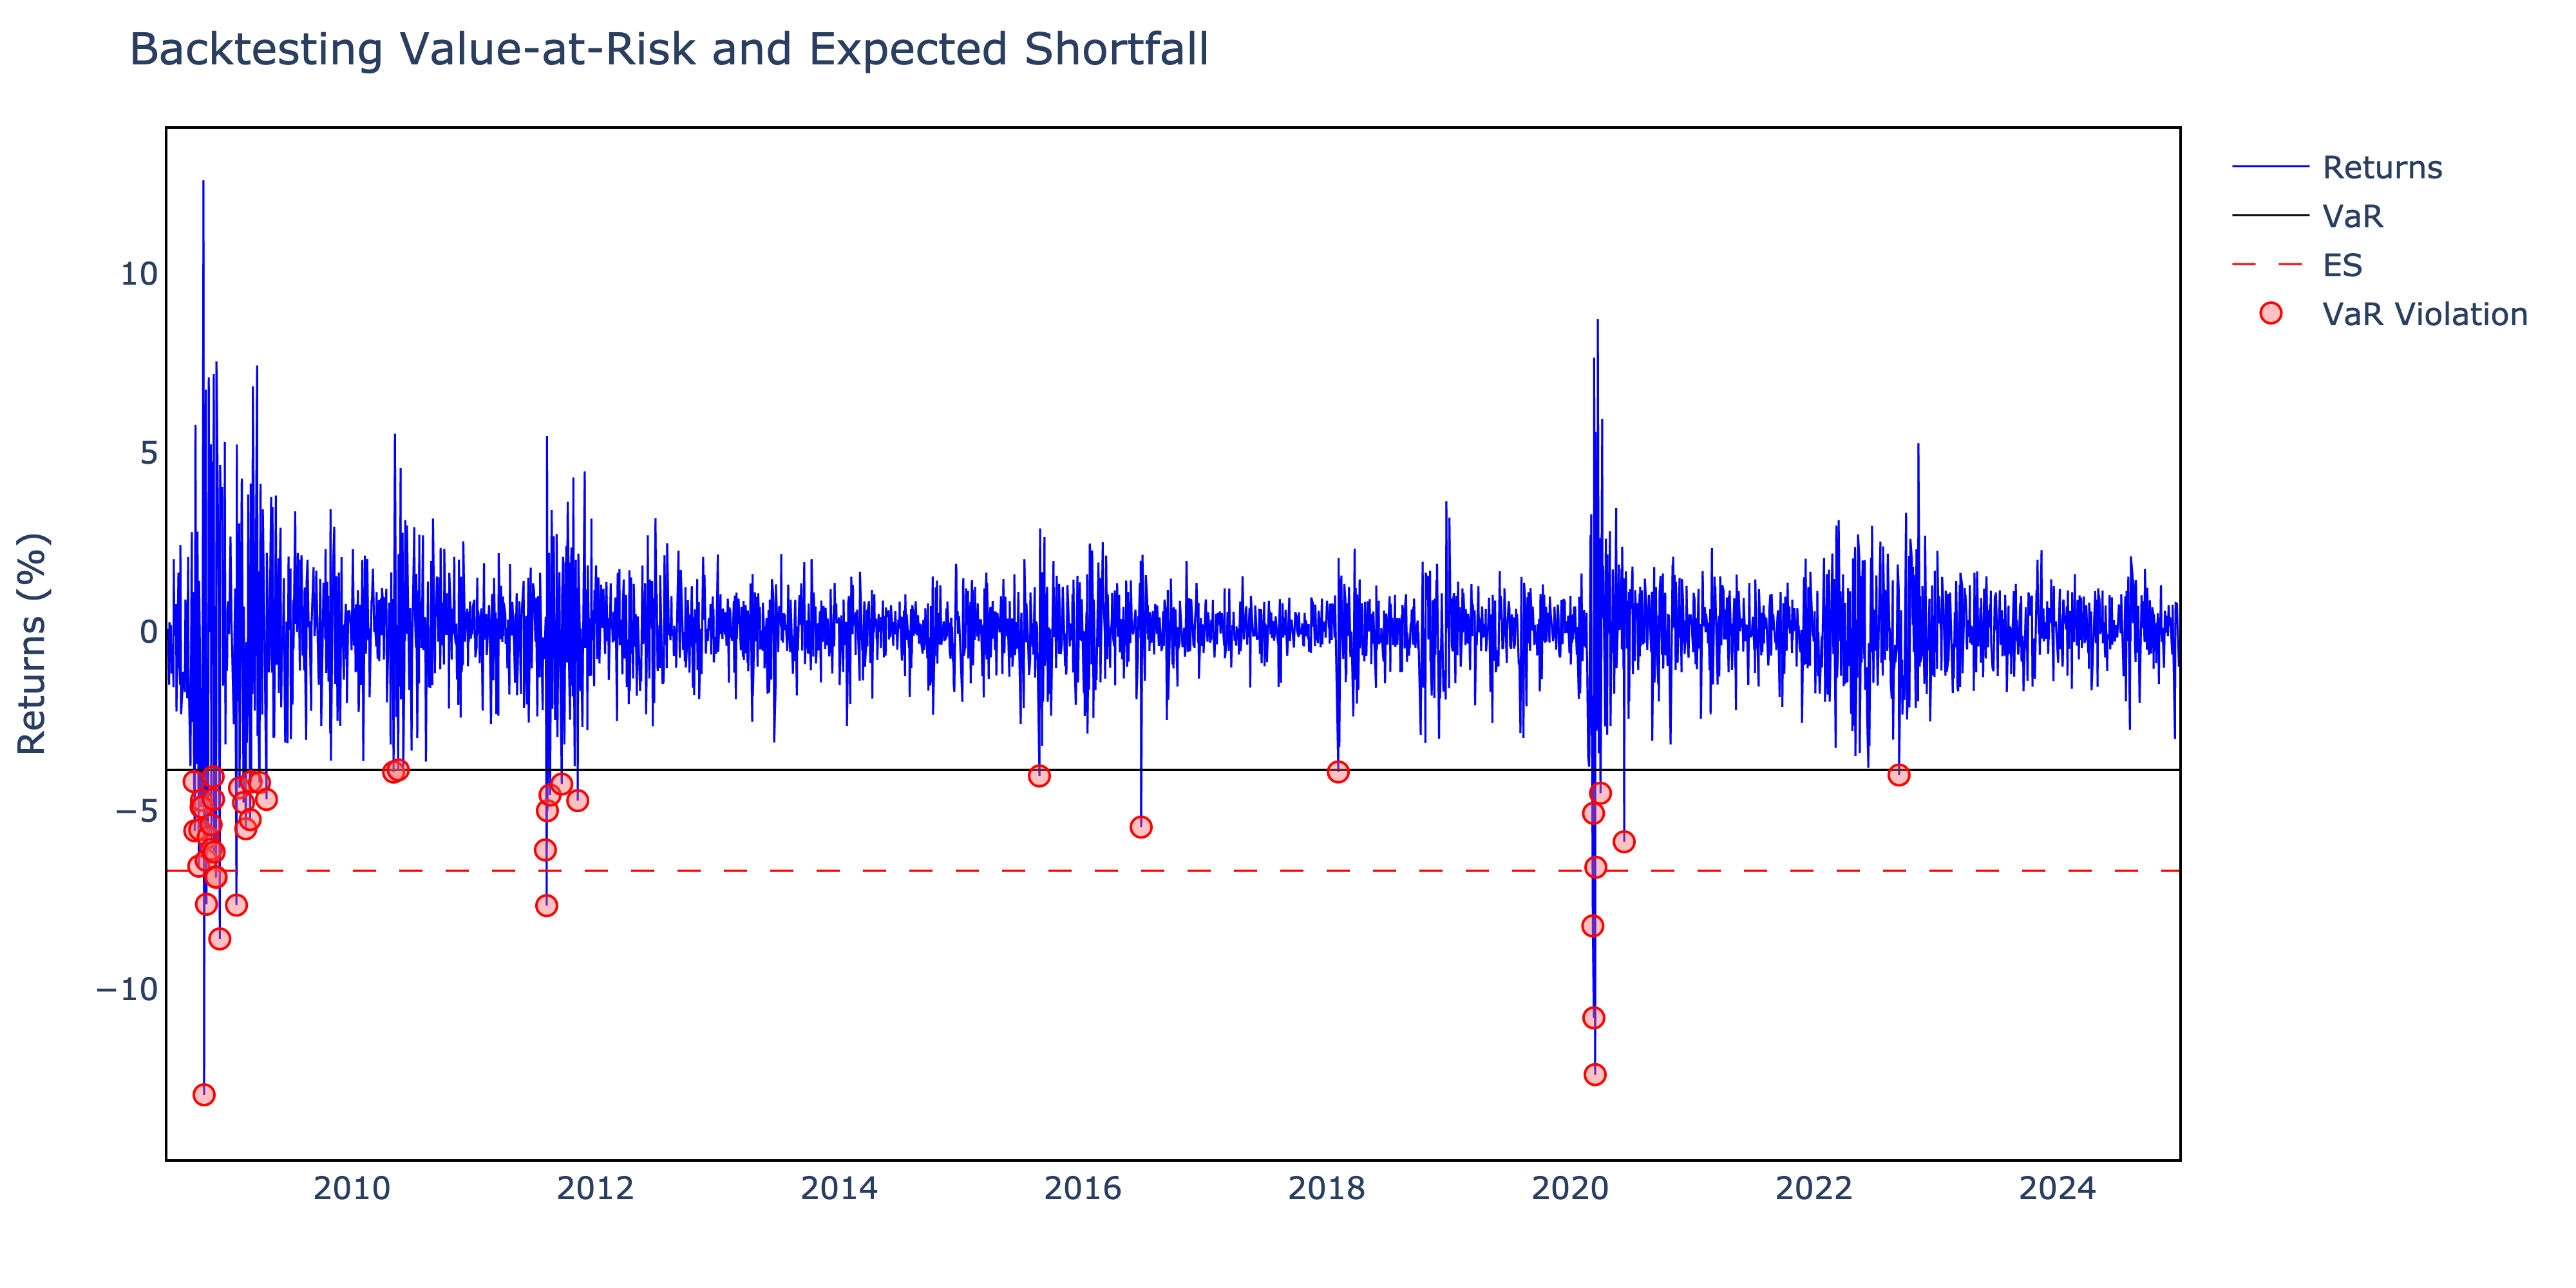

In [15]:
# Plot backtest
pv.plot_backtest(parametric_t_results, interactive=False) 

In [16]:
parametric_t_results.head()

,Returns,VaR,VaR Violation,VaR_monetary,ES,ES_monetary
Date,,,,,,
2008-06-27,-0.001615,0.038564,False,3856.433557,0.066761,6676.127018
2008-06-30,0.000807,0.038564,False,3856.433557,0.066761,6676.127018
2008-07-01,-0.008921,0.038564,False,3856.433557,0.066761,6676.127018
2008-07-02,-0.014773,0.038564,False,3856.433557,0.066761,6676.127018
2008-07-03,0.002684,0.038564,False,3856.433557,0.066761,6676.127018


#### Backtesting the Parametric Student-t Model

With the Student-t model, we observe **fewer violations**, showing better tail risk capture compared to the Normal model.

However, the key limitations remain: **violations are still clustered**. This key limitation will remain for all the models below.

In [17]:
# Apply Parametric Student-t VaR and ES
parametric_t_results = pv.parametric_var(vt_returns, confidence_level, distribution="t", wealth=wealth)
parametric_t_results = pv.parametric_es(parametric_t_results, confidence_level, distribution="t", wealth=wealth)

# Count violations
parametric_t_violations, parametric_t_violation_rate = pv.count_violations(parametric_t_results)

# Kupiec Test (Unconditional Coverage)
parametric_t_kupiec = pv.kupiec_test(
    total_violations=parametric_t_violations,
    total_days=len(parametric_t_results),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
parametric_t_christoffersen = pv.christoffersen_test(parametric_t_results)

# Joint Test (Conditional Coverage)
parametric_t_joint = pv.joint_lr_test(
    LR_uc=parametric_t_kupiec["LR_uc"],
    LR_c=parametric_t_christoffersen["LR_c"]
)

In [18]:
# Summary output
print(f"\n--- Parametric Student-t VaR Backtesting Summary ---")
print(f"Total Violations     : {parametric_t_violations}")
print(f"Violation Rate       : {parametric_t_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {parametric_t_kupiec['LR_uc']:.4f}")
print(f"p-value             : {parametric_t_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {parametric_t_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {parametric_t_christoffersen['LR_c']:.4f}")
print(f"p-value             : {parametric_t_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {parametric_t_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {parametric_t_joint['LR_total']:.4f}")
print(f"p-value             : {parametric_t_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {parametric_t_joint['reject_null']}")


--- Parametric Student-t VaR Backtesting Summary ---
Total Violations     : 46
Violation Rate       : 1.11%

Kupiec Test (UC):
LR_uc               : 0.4631
p-value             : 0.4962
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 20.0067
p-value             : 0.0000
Reject Null (5%)    : True

Joint Test (Conditional Coverage):
LR_total            : 20.4698
p-value             : 0.0000
Reject Null (5%)    : True


#### Student-t Assumption and Financial Returns

The graph below shows the Student's t assumption in action—clearly a more reasonable fit than the normal due to its ability to capture fat tails; however, important issues remain, such as its inability to account for skewness in financial returns.

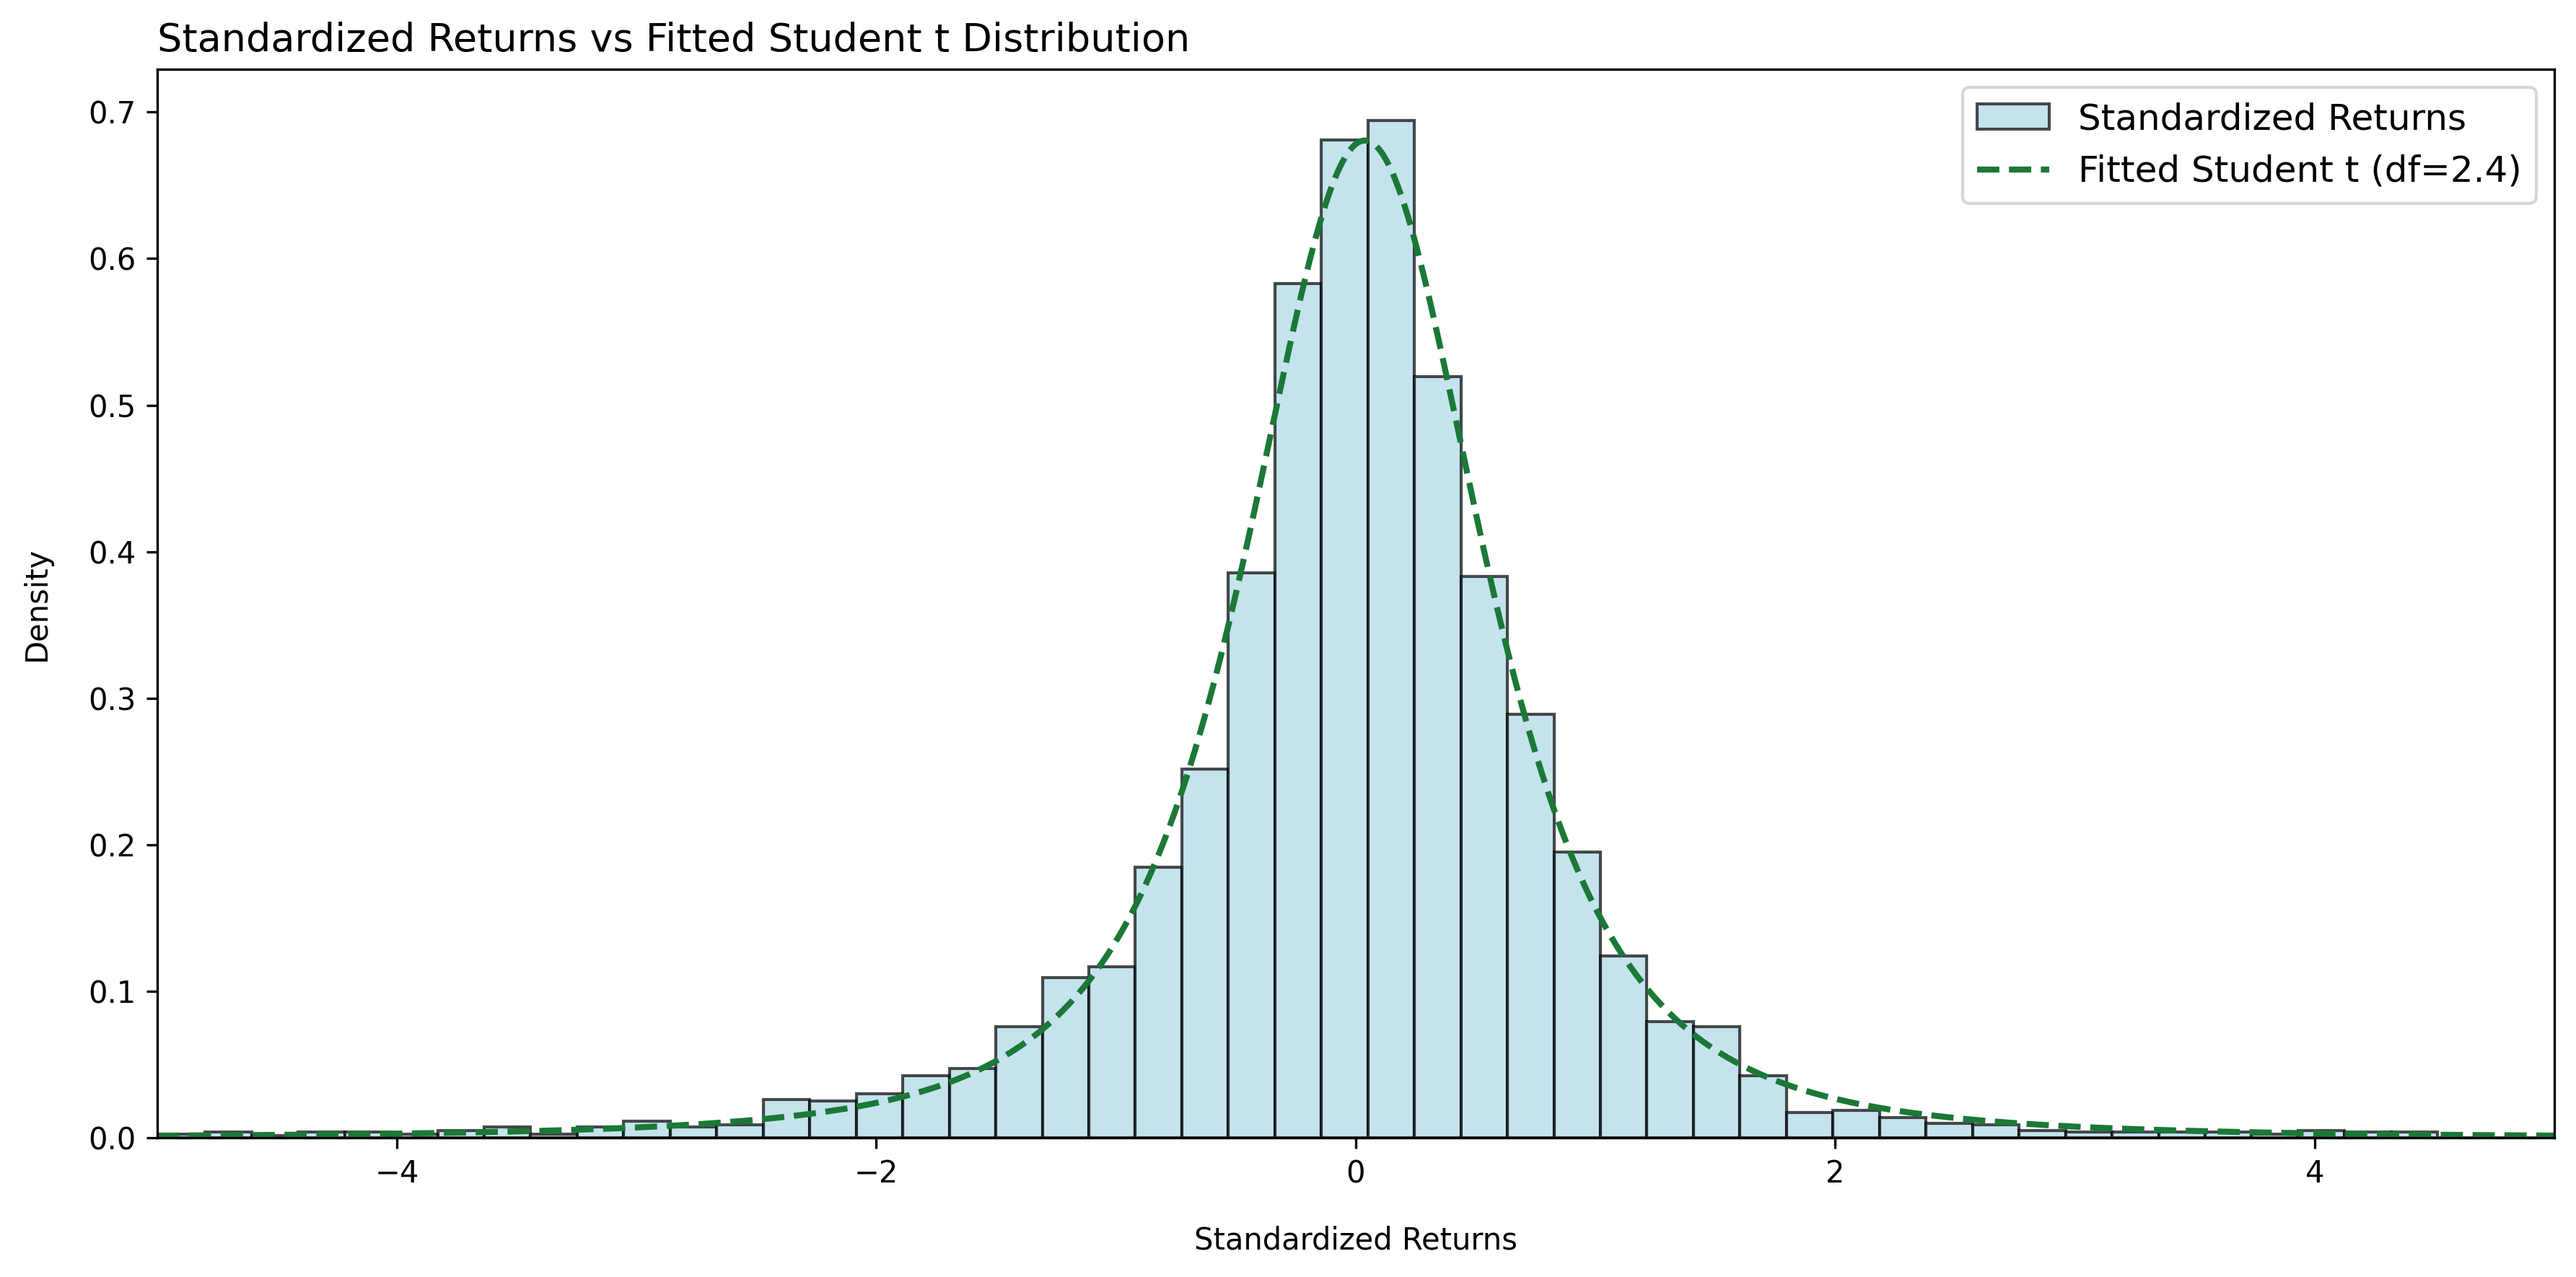

In [19]:
# Fit a Student's t-distribution to the standardized returns
df_t, loc_t, scale_t = t.fit(standardized_returns)

# Student t PDF using the fitted parameters
t_pdf = t.pdf(x_grid, df_t, loc=loc_t, scale=scale_t)

# Plot
plt.figure(figsize=(12, 6), dpi=300)

# Histogram
plt.hist(
    standardized_returns,
    bins=100,
    density=True,
    color='lightblue',
    alpha=0.7,
    edgecolor='black',
    label='Standardized Returns'
)

# Student t curve (strong green, solid line)
plt.plot(x_grid, t_pdf, color='#1b7837', linewidth=2, linestyle='--', label=f"Fitted Student t (df={df_t:.1f})")

# X-axis limits
plt.xlim(-5, 5)

# Labels and styling
plt.title("Standardized Returns vs Fitted Student t Distribution", loc="left", fontsize=13, fontweight="medium")
plt.xlabel("Standardized Returns", labelpad=12)
plt.ylabel("Density", labelpad=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [20]:
# Compute skewness
skewness_value = skew(vt_returns)

# Print result
print(f"Skewness of VT Returns: {skewness_value:.4f}")

Skewness of VT Returns: -0.6329


---

### Cornish-Fisher VaR

The Cornish-Fisher expansion adjusts the traditional Parametric VaR by incorporating **skewness** and **kurtosis** into the estimation. This allows for a more flexible model that accounts for **non-Normal features** of return distributions, such as **asymmetry** and **fat tails**.

This method extends the Normal VaR by modifying the quantile $z_\alpha$ using the **Cornish-Fisher expansion**:

$$
z_\alpha^{CF} = z_\alpha + \frac{1}{6}(z_\alpha^2 - 1) \cdot s + \frac{1}{24}(z_\alpha^3 - 3z_\alpha) \cdot k - \frac{1}{36}(2z_\alpha^3 - 5z_\alpha) \cdot s^2
$$

Where:
- $z_\alpha$ is the standard Normal quantile (e.g., 2.33 for 99%)
- $s$ is the skewness of the return distribution  
- $k$ is the excess kurtosis (kurtosis − 3) of the return distribution

The adjusted **Cornish-Fisher VaR** is then:

$$
\text{VaR}_\alpha^{CF} = \sigma \cdot z_\alpha^{CF}
$$

As with the Normal VaR, $\sigma$ is the standard deviation of returns. This model provides better tail risk estimates for **non-Normal** return distributions, without requiring a fully non-parametric method.

Note: Cornish-Fisher VaR may produce inaccurate estimates when skewness or kurtosis is extreme. It is best suited when the distribution deviates moderately from Normality.


In [21]:
# Apply Parametric VaR model 
cf_results = pv.cornish_fisher_var(vt_returns, confidence_level, wealth=wealth) 


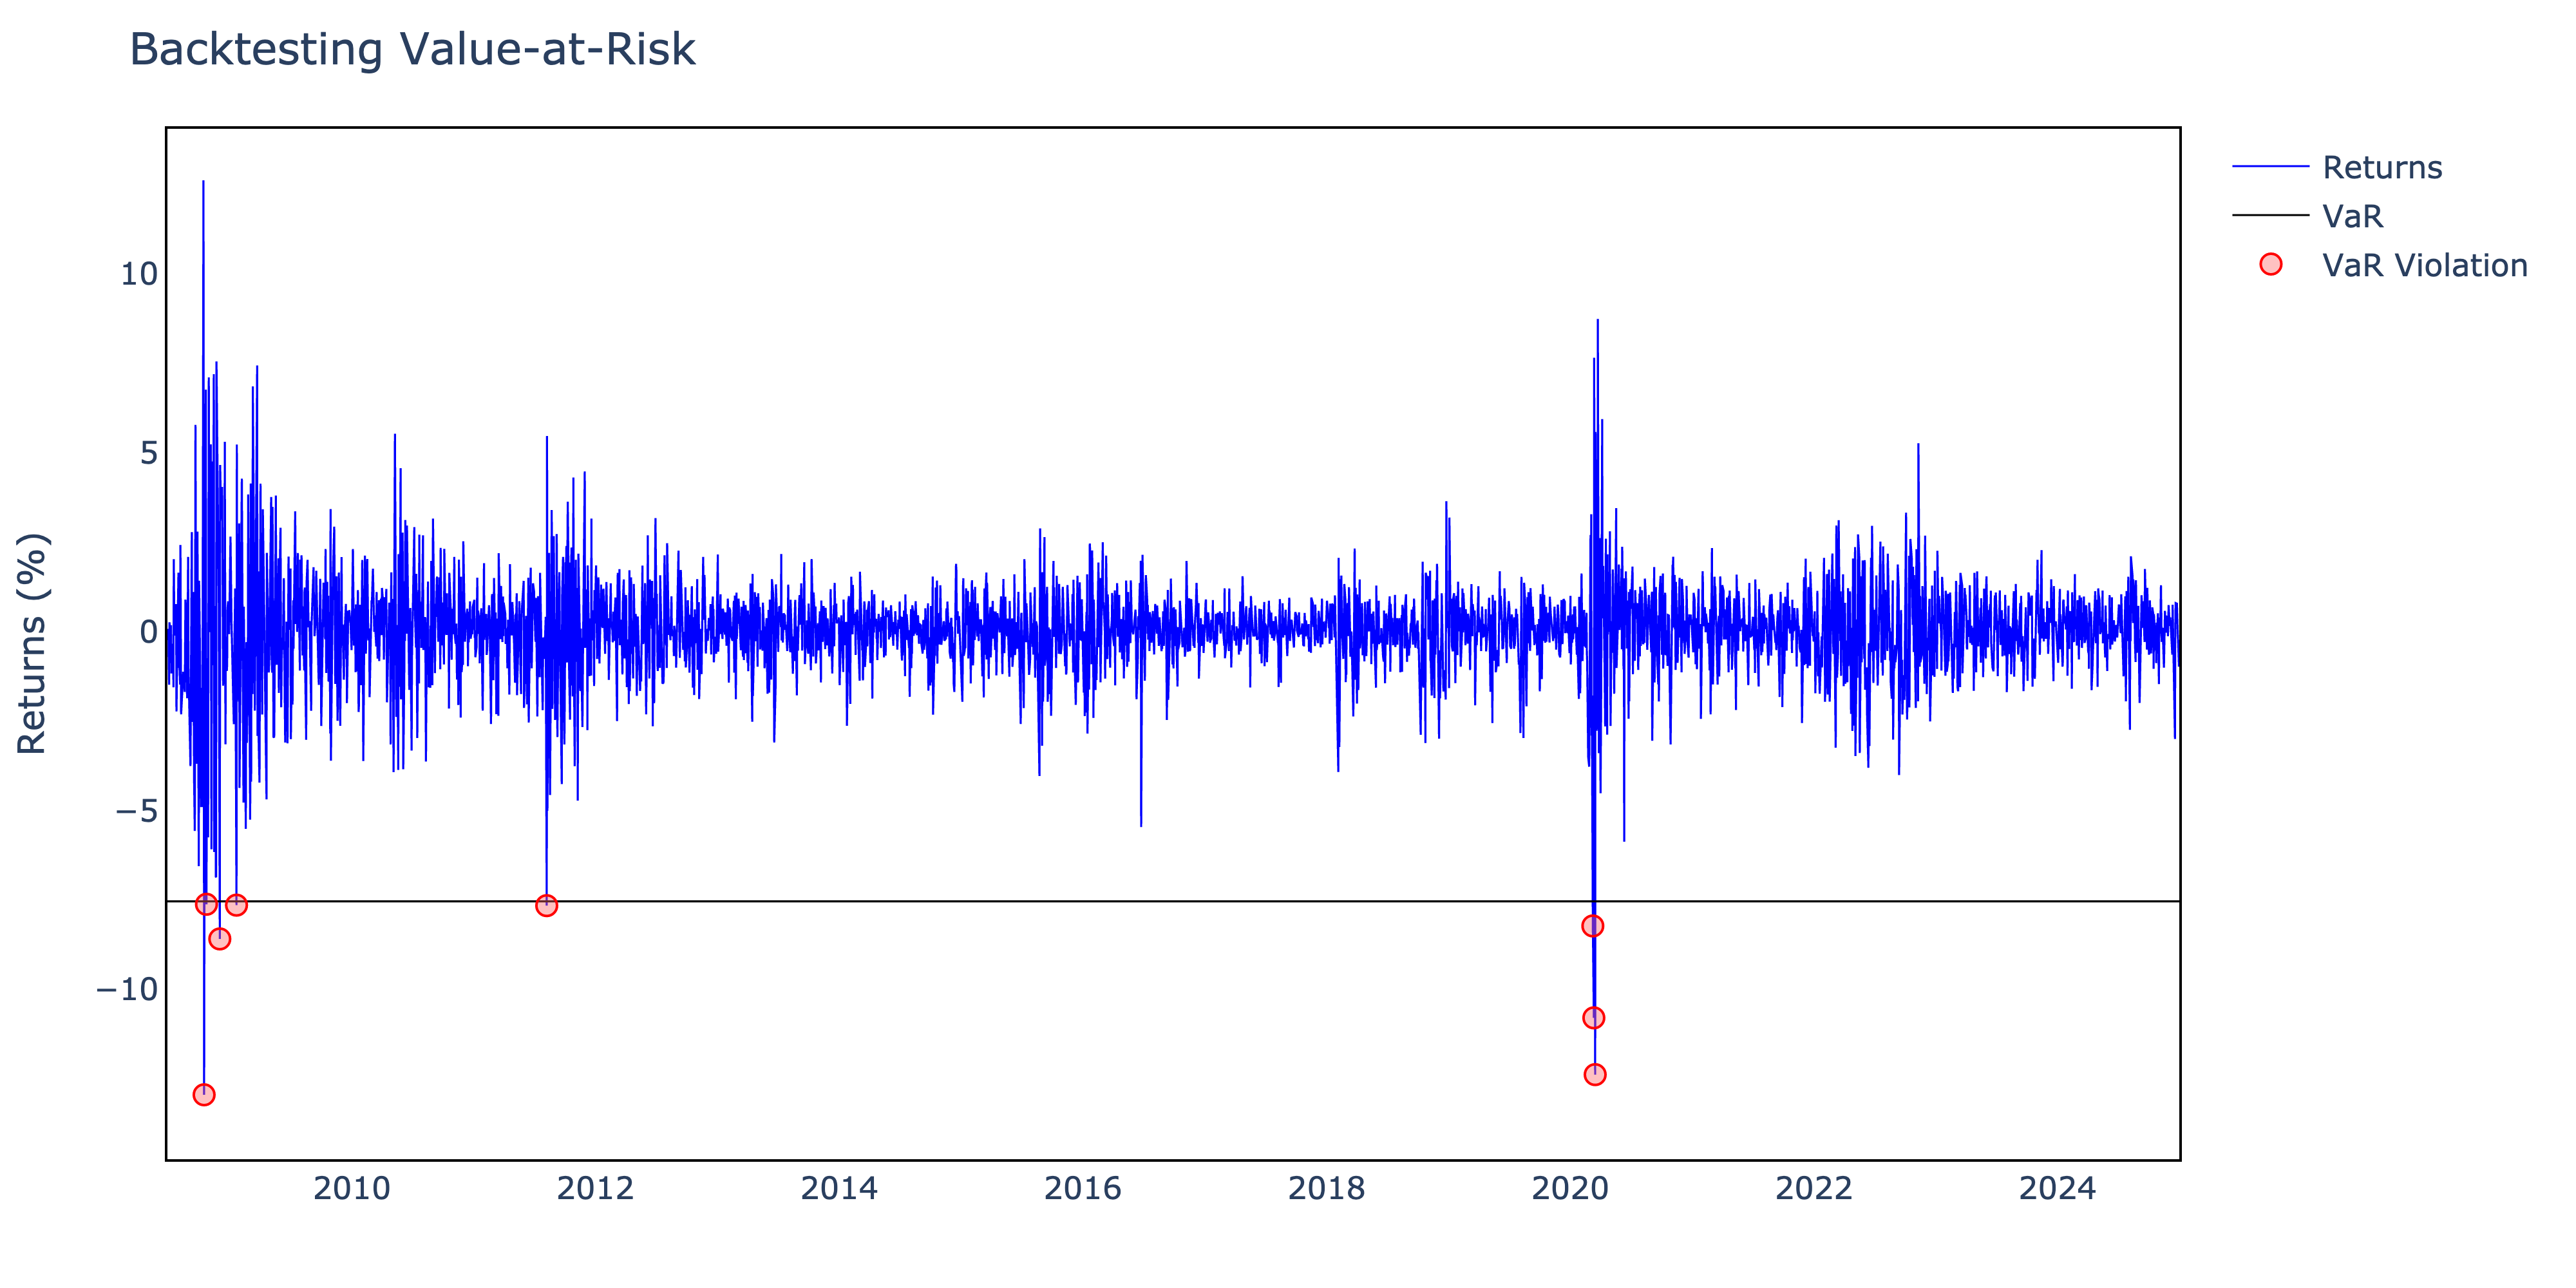

In [22]:
# Plot backtest
pv.plot_backtest(cf_results, interactive=False) 

In [23]:
cf_results.head()

,Returns,VaR,VaR Violation,VaR_monetary
Date,,,,
2008-06-27,-0.001615,0.075343,False,7534.285067
2008-06-30,0.000807,0.075343,False,7534.285067
2008-07-01,-0.008921,0.075343,False,7534.285067
2008-07-02,-0.014773,0.075343,False,7534.285067
2008-07-03,0.002684,0.075343,False,7534.285067


#### Limitations of Cornish-Fisher VaR

The Cornish-Fisher method adjusts VaR for skewness and kurtosis, but can become unreliable when these moments are large. The expansion may **over-correct the quantile**, exaggerating tail risk.

For example, with strong skewness and excess kurtosis, $z^*_\alpha$ can shift far beyond what the true distribution justifies — as seen in this case, where it drops from -2.33 to -5.71.

Use Cornish-Fisher with **caution**, especially when deviations from Normality are large. Always compare with standard and non-parametric estimates.

In [24]:
# Compute sample statistics
sample_mean = vt_returns.mean()
sample_std = vt_returns.std()
sample_skewness = skew(vt_returns)
sample_kurtosis = kurtosis(vt_returns, fisher=True)  # excess kurtosis

# Confidence level
confidence_level = 0.99
z = norm.ppf(1 - confidence_level)

# Cornish-Fisher expansion terms
term1 = (1 / 6) * (z**2 - 1) * sample_skewness
term2 = (1 / 24) * (z**3 - 3 * z) * sample_kurtosis
term3 = (1 / 36) * (2 * z**3 - 5 * z) * (sample_skewness**2)

# Adjusted quantile
z_cf = z + term1 + term2 - term3

In [25]:
# Print breakdown
print(f"Mean:           {sample_mean:.5f}")
print(f"Std Dev:        {sample_std:.5f}")
print(f"Skewness:       {sample_skewness:.5f}")
print(f"Excess Kurtosis:       {sample_kurtosis:.5f}\n")

print(f"z (normal):        {z:.5f}")
print(f"Term1 (skew):      {term1:.5f}")
print(f"Term2 (kurtosis):  {term2:.5f}")
print(f"Term3 (skew^2):    {term3:.5f}")
print(f"z* (adjusted):     {z_cf:.5f}")

Mean:           0.00029
Std Dev:        0.01318
Skewness:       -0.63293
Excess Kurtosis:       13.15973

z (normal):        -2.32635
Term1 (skew):      -0.46541
Term2 (kurtosis):  -3.07658
Term3 (skew^2):    -0.15076
z* (adjusted):     -5.71757


---

### Historical VaR (Non-Parametric)

Historical VaR estimates risk using the **empirical distribution** of past returns, with **no distributional assumptions**. Losses are defined as:

$$
\ell_t = -r_t
$$

The VaR at confidence level $\alpha$ is the empirical quantile at level $1 - \alpha$:

$$
\text{VaR}_\alpha = \text{Quantile}_{1 - \alpha}(\ell_t)
$$

The corresponding Expected Shortfall (ES) is the **average of losses exceeding VaR**:

$$
\text{ES}_\alpha = \mathbb{E}[\ell_t \mid \ell_t \ge \text{VaR}_\alpha]
$$

This method is simple and captures **fat tails** well, but treats all past data equally — ignoring the importance of recent events.


In [26]:
# Apply Parametric VaR model 
historical_results = pv.historical_var(vt_returns, confidence_level, wealth=wealth) 

# Compute ES for the whole period
historical_results = pv.historical_es(historical_results, wealth=wealth)


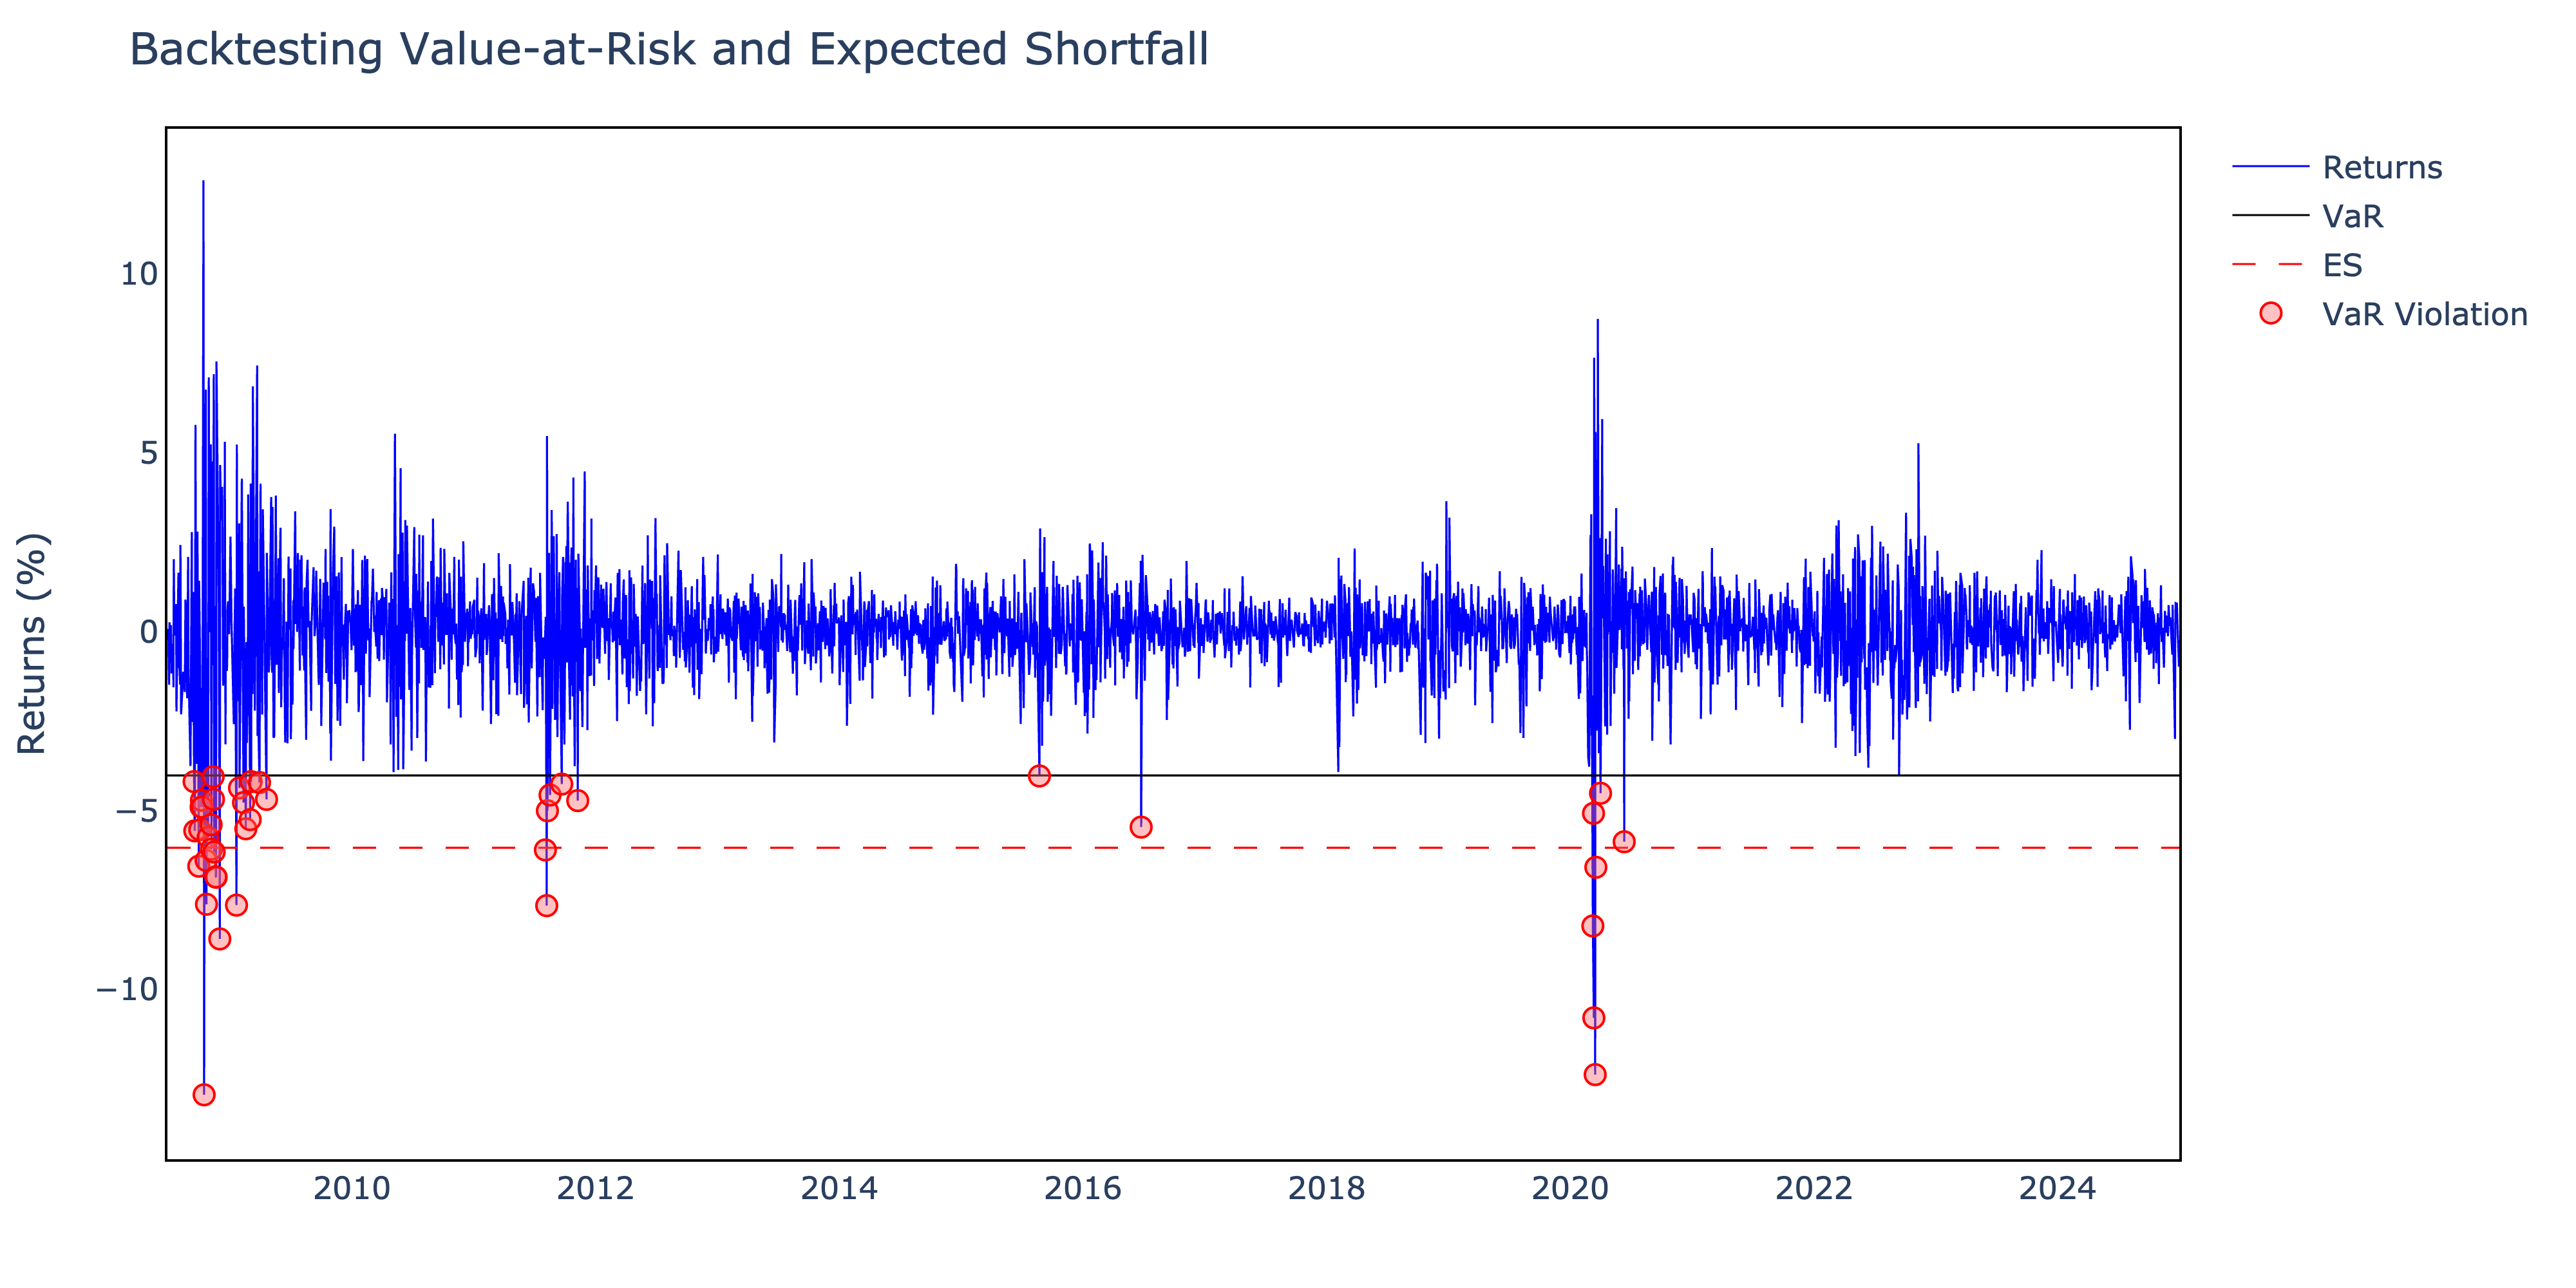

In [27]:
# Plot backtest
pv.plot_backtest(historical_results, interactive=False)

In [28]:
historical_results.head()

,Returns,VaR,VaR Violation,VaR_monetary,ES,ES_monetary
Date,,,,,,
2008-06-27,-0.001615,0.040132,False,4013.2187,0.060345,6034.535994
2008-06-30,0.000807,0.040132,False,4013.2187,0.060345,6034.535994
2008-07-01,-0.008921,0.040132,False,4013.2187,0.060345,6034.535994
2008-07-02,-0.014773,0.040132,False,4013.2187,0.060345,6034.535994
2008-07-03,0.002684,0.040132,False,4013.2187,0.060345,6034.535994


#### Backtesting Historical VaR

The Historical VaR model often shows better performance than the Normal model because it captures fat tails directly from past data. 

In [29]:
# Count violations
historical_violations, historical_violation_rate = pv.count_violations(historical_results)

# Kupiec Test (Unconditional Coverage)
historical_kupiec = pv.kupiec_test(
    total_violations=historical_violations,
    total_days=len(historical_results),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
historical_christoffersen = pv.christoffersen_test(historical_results)

# Joint Test (Conditional Coverage)
historical_joint = pv.joint_lr_test(
    LR_uc=historical_kupiec["LR_uc"],
    LR_c=historical_christoffersen["LR_c"]
)

In [30]:
# Summary output
print(f"\n--- Historical VaR Backtesting Summary ---")
print(f"Total Violations     : {historical_violations}")
print(f"Violation Rate       : {historical_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {historical_kupiec['LR_uc']:.4f}")
print(f"p-value             : {historical_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {historical_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {historical_christoffersen['LR_c']:.4f}")
print(f"p-value             : {historical_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {historical_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {historical_joint['LR_total']:.4f}")
print(f"p-value             : {historical_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {historical_joint['reject_null']}")


--- Historical VaR Backtesting Summary ---
Total Violations     : 42
Violation Rate       : 1.01%

Kupiec Test (UC):
LR_uc               : 0.0047
p-value             : 0.9454
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 22.2057
p-value             : 0.0000
Reject Null (5%)    : True

Joint Test (Conditional Coverage):
LR_total            : 22.2104
p-value             : 0.0000
Reject Null (5%)    : True


---

### Hybrid VaR (Exponentially Weighted Historical)

Hybrid VaR improves on the Historical method by giving **more weight to recent returns** using exponential decay. It forms a **weighted empirical distribution**, then estimates the quantile:

Weights are computed as:

$$
w_t = \alpha_0 \cdot \lambda^{t}, \quad t = 0, 1, \dots, n-1
$$

with:

$$
\alpha_0 = \frac{1 - \lambda}{\lambda \cdot (1 - \lambda^n)}
$$

Here:
- $\lambda \in (0,1)$ is the **decay factor** (e.g., 0.94)
- $n$ is the total number of return observations
- Weights are then normalized: $\sum_{t=0}^{n-1} w_t = 1$

VaR is the **weighted quantile** at level $1 - \alpha$:

$$
\text{VaR}_\alpha = \text{Weighted Quantile}_{1 - \alpha}(\ell_t)
$$

Expected Shortfall (ES) is the **weighted average** of tail losses:

$$
\text{ES}_\alpha = \frac{\sum_{t: \ell_t \ge \text{VaR}_\alpha} w_t \cdot \ell_t}{\sum_{t: \ell_t \ge \text{VaR}_\alpha} w_t}
$$

This model better tracks **changing volatility** and **recent shocks**. 

#### Exponential Weight Decay in Hybrid VaR

The speed of reactivity in Hybrid VaR is controlled by the decay parameter $\lambda$:

- A **lower $\lambda$** (e.g., 0.85) emphasizes the most recent returns, making the estimate **highly sensitive** to new information — useful in volatile or stressed markets.
- A **higher $\lambda$** (e.g., 0.99) spreads weights more evenly across the data, producing a **smoother**, less reactive estimate — better suited for stable conditions or long-term risk views.

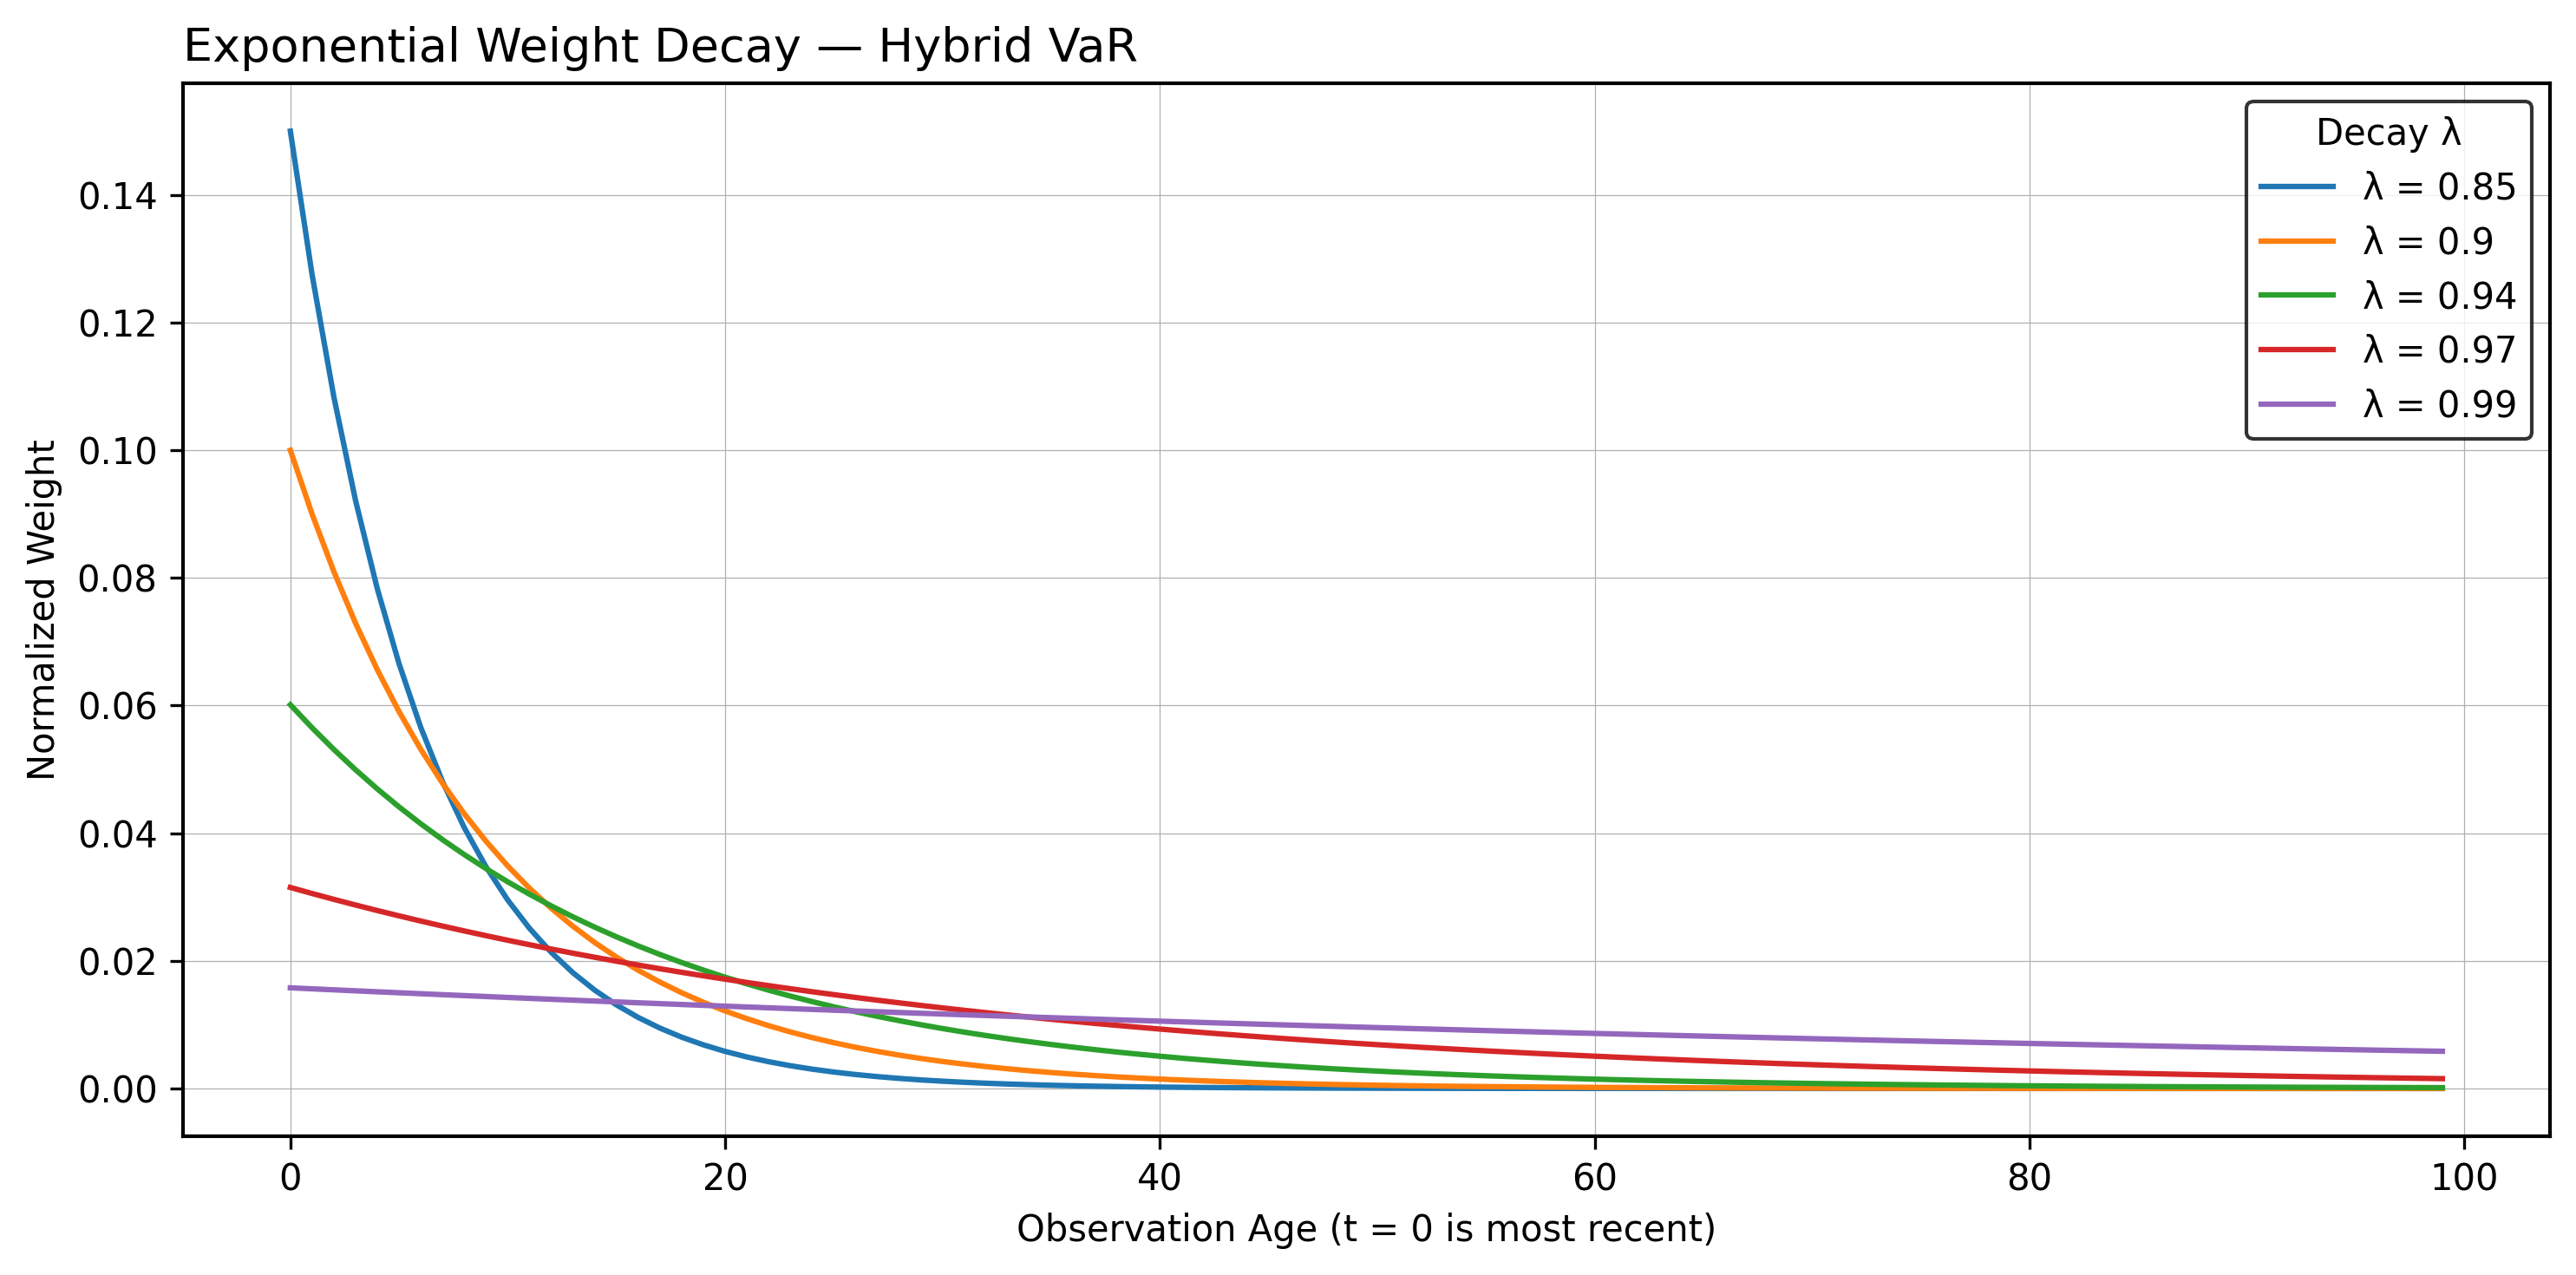

In [31]:
# Settings
num_observations = 100
observation_range = np.arange(num_observations)
lambda_values = [0.85, 0.90, 0.94, 0.97, 0.99]

# Compute weights for each lambda
weight_matrix = {}
for lambda_decay in lambda_values:
    alpha0 = (1 - lambda_decay) / (lambda_decay * (1 - lambda_decay**num_observations))
    raw_weights = alpha0 * lambda_decay**observation_range
    normalized_weights = raw_weights / raw_weights.sum()
    weight_matrix[lambda_decay] = normalized_weights

# Plot
plt.figure(figsize=(10, 5), dpi=300)

for lambda_decay, weights in weight_matrix.items():
    plt.plot(observation_range, weights, label=f"λ = {lambda_decay}")

# Title and labels
plt.title("Exponential Weight Decay — Hybrid VaR", loc="left", fontsize=13, fontweight="medium")
plt.xlabel("Observation Age (t = 0 is most recent)")
plt.ylabel("Normalized Weight")

# Black box styling
ax = plt.gca()
for side in ['top', 'bottom', 'left', 'right']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1)

ax.tick_params(width=0.8, color='black')

# Grid and legend
plt.grid(True, linewidth=0.3)
plt.legend(title="Decay λ", frameon=True, edgecolor="black")
plt.tight_layout()
plt.show()


In [32]:
lambda_decay=0.97

In [33]:
# Apply Hybrid VaR model 
hybrid_results = pv.hybrid_var(vt_returns, confidence_level, lambda_decay=lambda_decay, wealth=wealth) 

# Compute ES for the whole period
hybrid_results = pv.hybrid_es(hybrid_results, lambda_decay=lambda_decay, wealth=wealth)


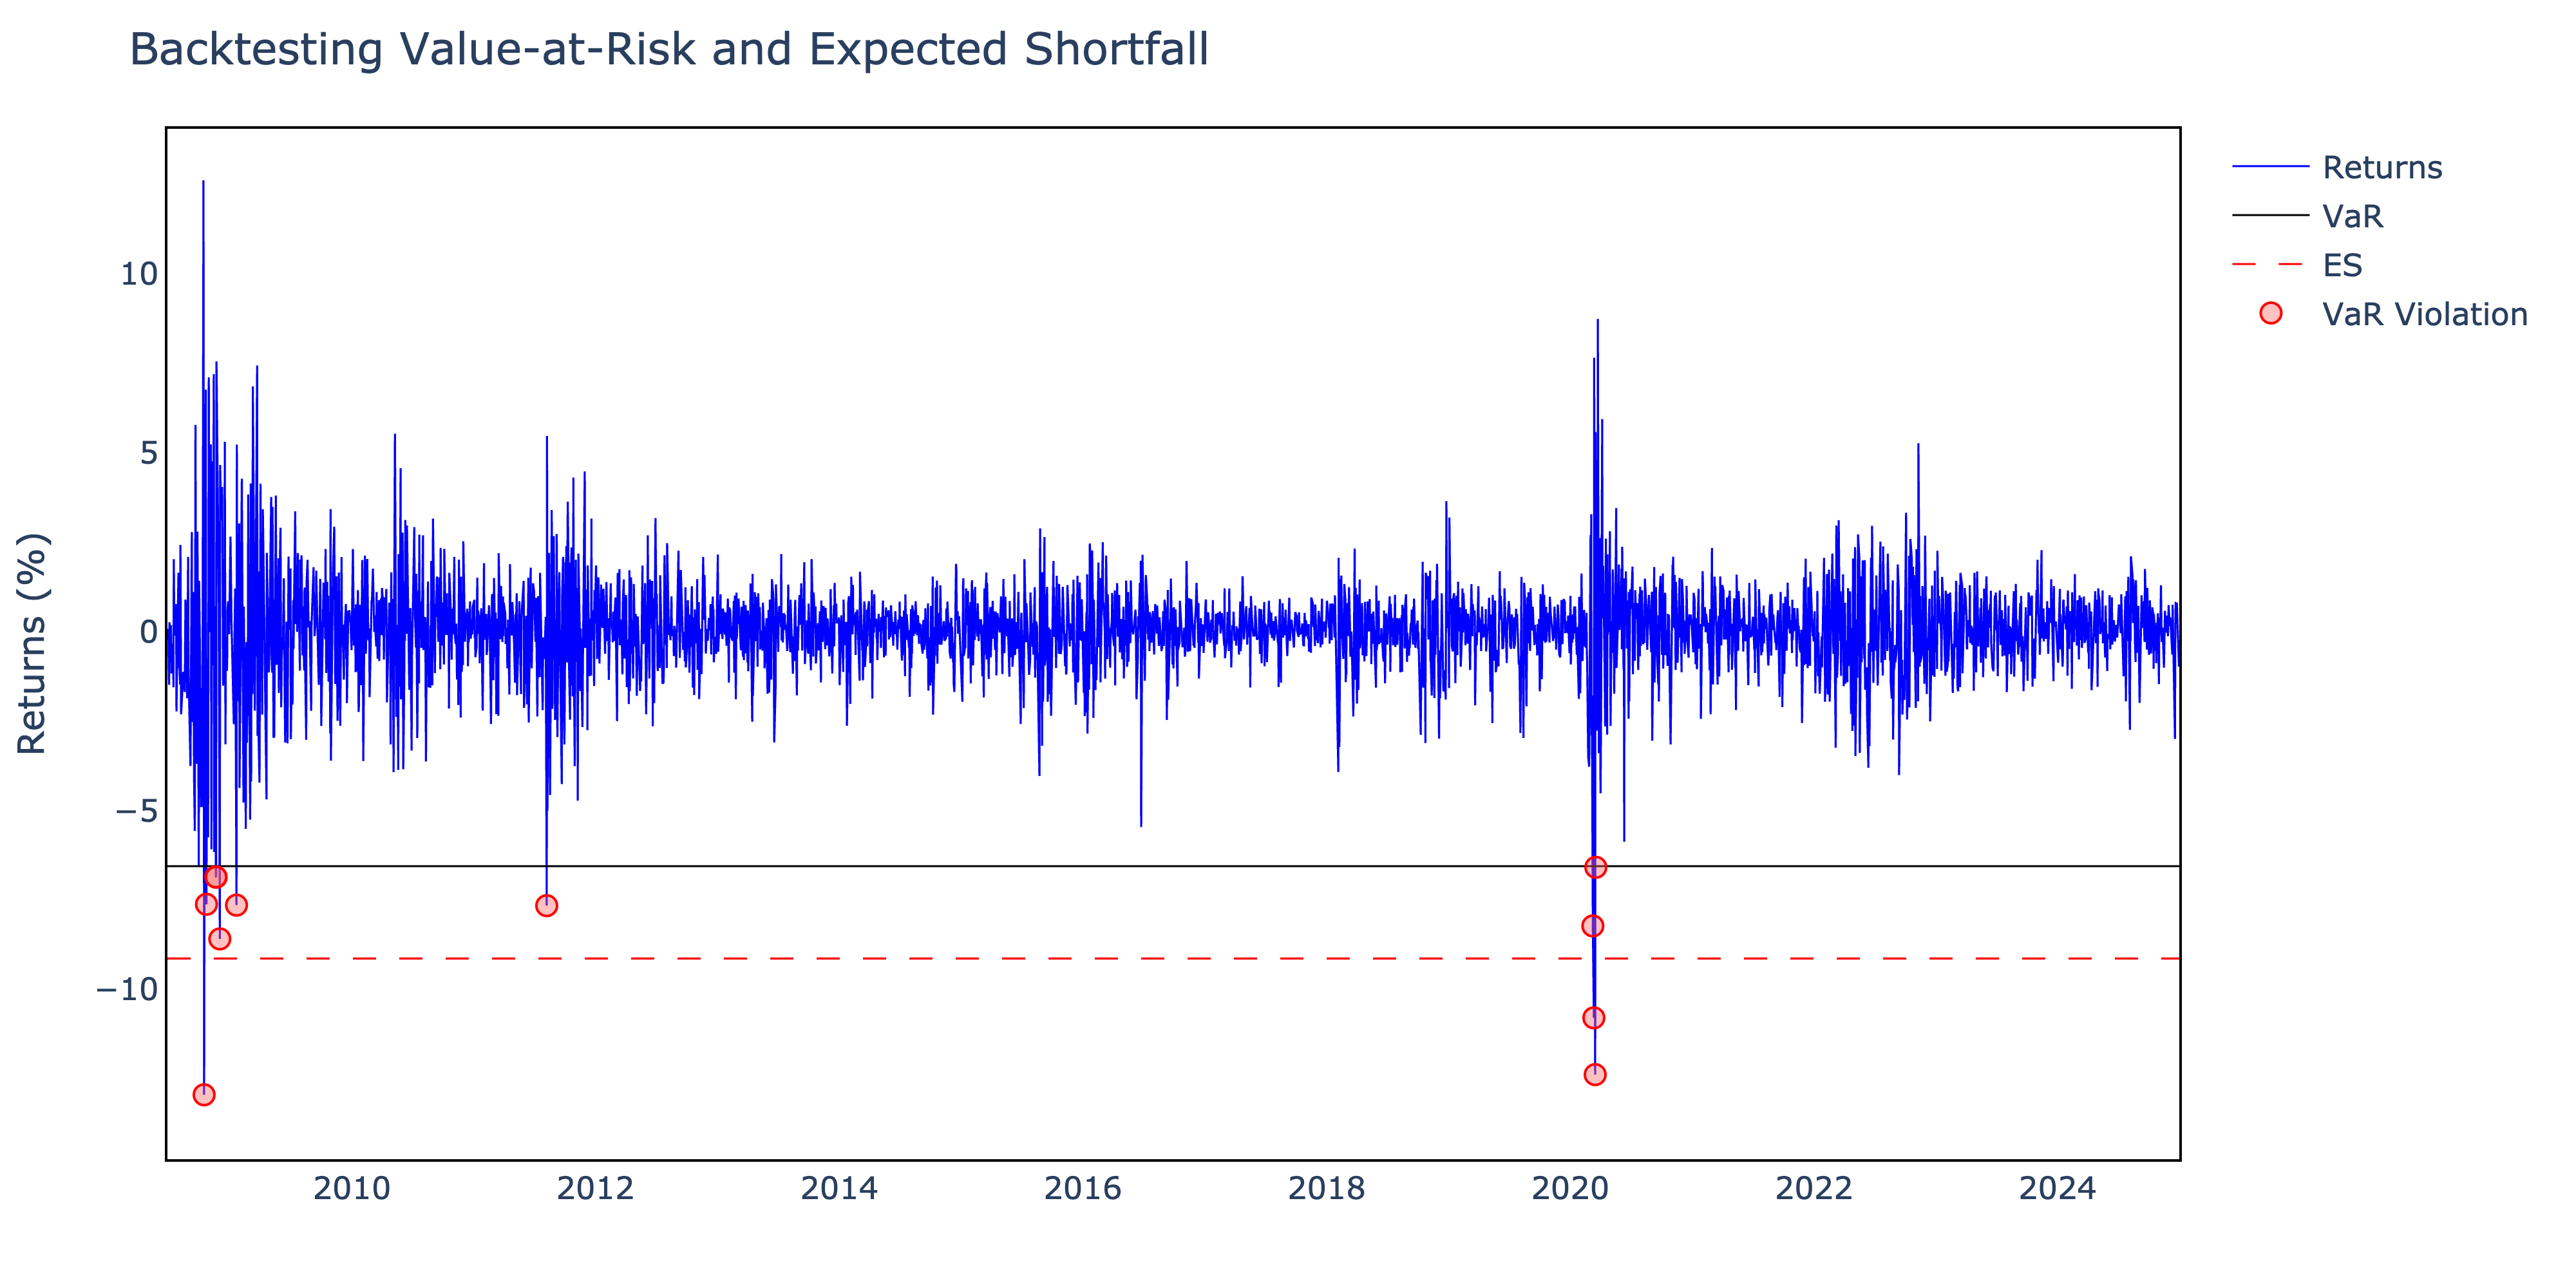

In [34]:
# Plot backtest
pv.plot_backtest(hybrid_results, interactive=False)

In [35]:
hybrid_results.head()

,Returns,VaR,VaR Violation,VaR_monetary,ES,ES_monetary
Date,,,,,,
2008-06-27,-0.001615,0.065496,False,6549.588513,0.091304,9130.415372
2008-06-30,0.000807,0.065496,False,6549.588513,0.091304,9130.415372
2008-07-01,-0.008921,0.065496,False,6549.588513,0.091304,9130.415372
2008-07-02,-0.014773,0.065496,False,6549.588513,0.091304,9130.415372
2008-07-03,0.002684,0.065496,False,6549.588513,0.091304,9130.415372
